# Heart Disease Prediction
## Notebook 2: Exploratory Data Analysis

This notebook explores the cleaned dataset to understand feature distributions,
class balance, correlations with the target variable, and outlier presence.
Findings from this analysis inform the feature engineering and modelling decisions
in subsequent notebooks.

Input: heart_disease.csv (908 rows, 14 columns)

In [1]:
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_DIR = os.path.join('..', 'data', 'processed', 'heart_disease.csv')

### Data Overview

In [3]:
df = pd.read_csv(DATA_DIR)
df.shape

(908, 14)

In [4]:
df.dtypes

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000
mean,53.526432,0.794053,3.247797,132.075991,245.126652,0.153084,0.614537,136.466410,0.422907,0.906828,1.842511,0.479075,6.063877,0.546256
std,9.429034,0.404615,0.939895,17.876884,51.562386,0.360267,0.810004,25.415624,0.494293,1.043998,0.514914,0.848244,1.653000,0.498130
min,28.000000,0.000000,1.000000,80.000000,85.000000,0.000000,0.000000,60.000000,0.000000,-2.000000,1.000000,0.000000,3.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,219.000000,0.000000,0.000000,120.000000,0.000000,0.000000,2.000000,0.000000,6.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,238.000000,0.000000,0.000000,138.000000,0.000000,0.700000,2.000000,0.000000,7.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,267.000000,0.000000,1.000000,155.000000,1.000000,1.500000,2.000000,1.000000,7.000000,1.000000
max,80.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


### Class Distribution

In [6]:
col = df['target']
counts = col.value_counts()
print(counts)

target
1    496
0    412
Name: count, dtype: int64


In [7]:
total = len(col)
ratio = col.value_counts() / total
print(ratio)

target
1    0.546256
0    0.453744
Name: count, dtype: float64


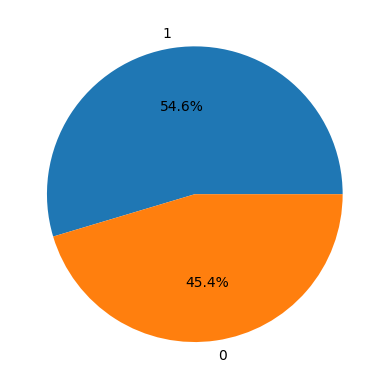

In [8]:
counts.plot(kind='pie', autopct='%1.1f%%')
plt.show()

### Continuous Feature Distributions

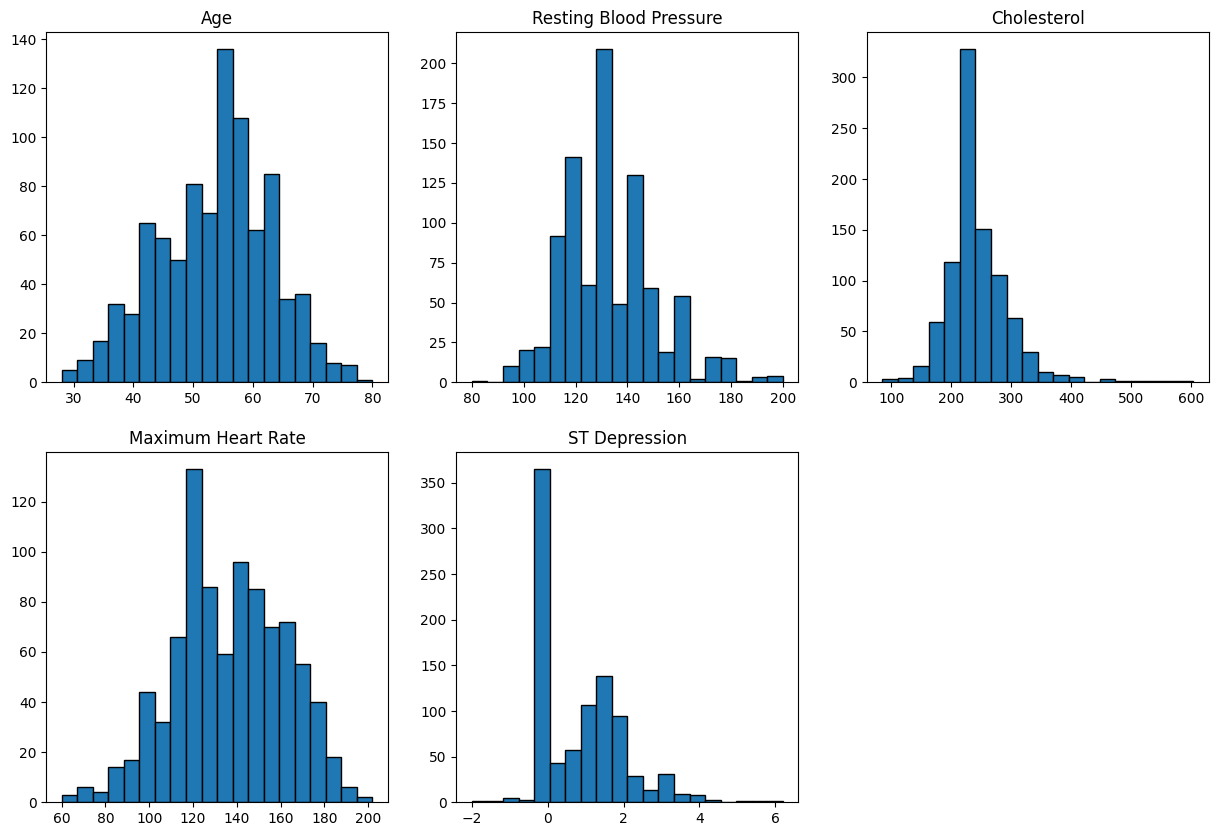

In [9]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax[0, 0].hist(df['age'], bins=20, edgecolor='black')
ax[0, 0].set_title('Age')
ax[0, 1].hist(df['trestbps'], bins=20, edgecolor='black')
ax[0, 1].set_title('Resting Blood Pressure')
ax[0, 2].hist(df['chol'], bins=20, edgecolor='black')
ax[0, 2].set_title('Cholesterol')
ax[1, 0].hist(df['thalach'], bins=20, edgecolor='black')
ax[1, 0].set_title('Maximum Heart Rate')
ax[1, 1].hist(df['oldpeak'], bins=20, edgecolor='black')
ax[1, 1].set_title('ST Depression')
ax[1,2].set_visible(False)

### Categorical Feature Distributions

Text(0.5, 1.0, 'Thalassemia')

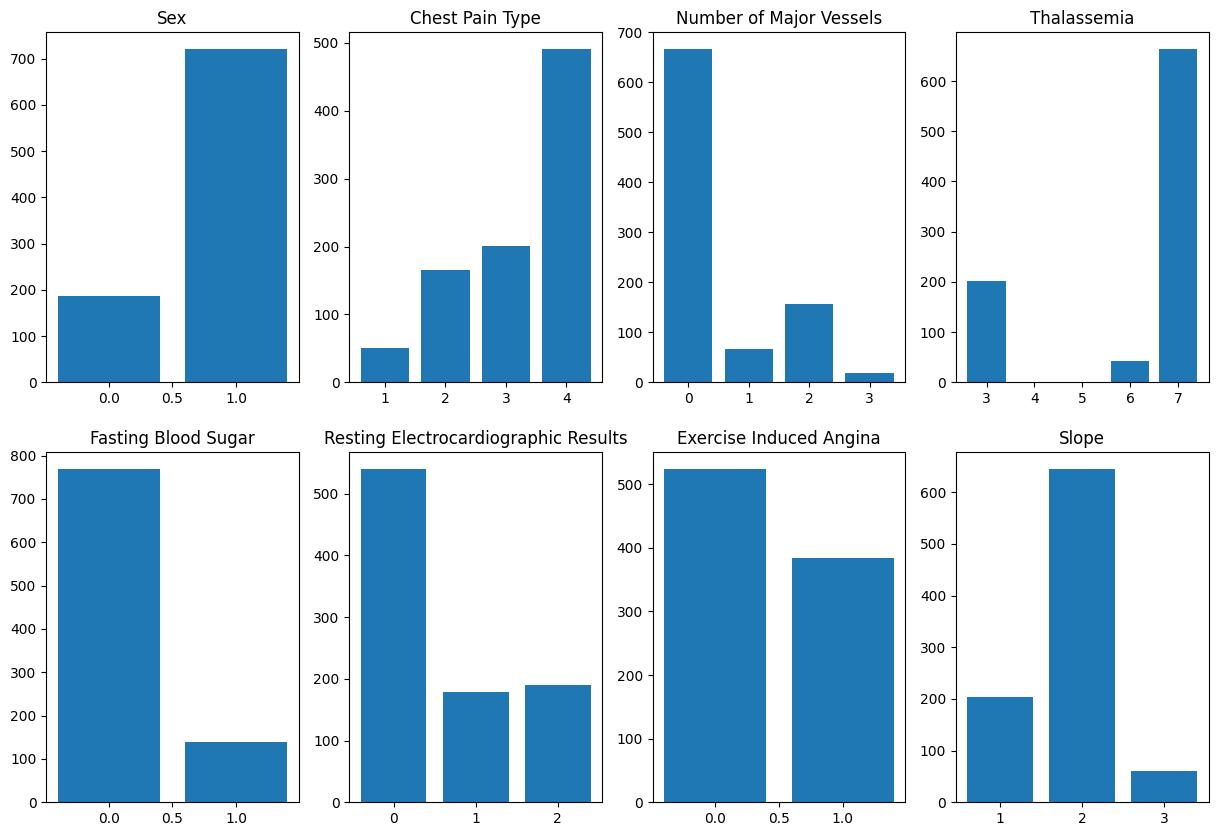

In [10]:
fig, ax = plt.subplots(2, 4, figsize=(15, 10))
ax[0, 0].bar(df['sex'].value_counts().index, df['sex'].value_counts().values)
ax[0, 0].set_title('Sex')
ax[0, 1].bar(df['cp'].value_counts().index, df['cp'].value_counts().values)
ax[0, 1].set_title('Chest Pain Type')      
ax[1, 0].bar(df['fbs'].value_counts().index, df['fbs'].value_counts().values)
ax[1, 0].set_title('Fasting Blood Sugar')
ax[1, 1].bar(df['restecg'].value_counts().index, df['restecg'].value_counts().values)
ax[1, 1].set_title('Resting Electrocardiographic Results')
ax[1, 2].bar(df['exang'].value_counts().index, df['exang'].value_counts().values)
ax[1, 2].set_title('Exercise Induced Angina')
ax[1, 3].bar(df['slope'].value_counts().index, df['slope'].value_counts().values)
ax[1, 3].set_title('Slope')      
ax[0, 2].bar(df['ca'].value_counts().index, df['ca'].value_counts().values)
ax[0, 2].set_title('Number of Major Vessels')
ax[0, 3].bar(df['thal'].value_counts().index, df['thal'].value_counts().values)
ax[0, 3].set_title('Thalassemia')

### Outlier Analysis

In [11]:
def outlier_flag(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return lower_bound, upper_bound

In [12]:
chol_lb, chol_ub = outlier_flag(df, 'chol')
op_lb, op_ub = outlier_flag(df, 'oldpeak')

print(f"Chol outliers: bounds: {chol_lb:.2f}, {chol_ub:.2f}")
print(f"Oldpeak outliers: bounds: {op_lb:.2f}, {op_ub:.2f}")

Chol outliers: bounds: 147.00, 339.00
Oldpeak outliers: bounds: -2.25, 3.75


### Bivariate Analysis: Feature vs Target

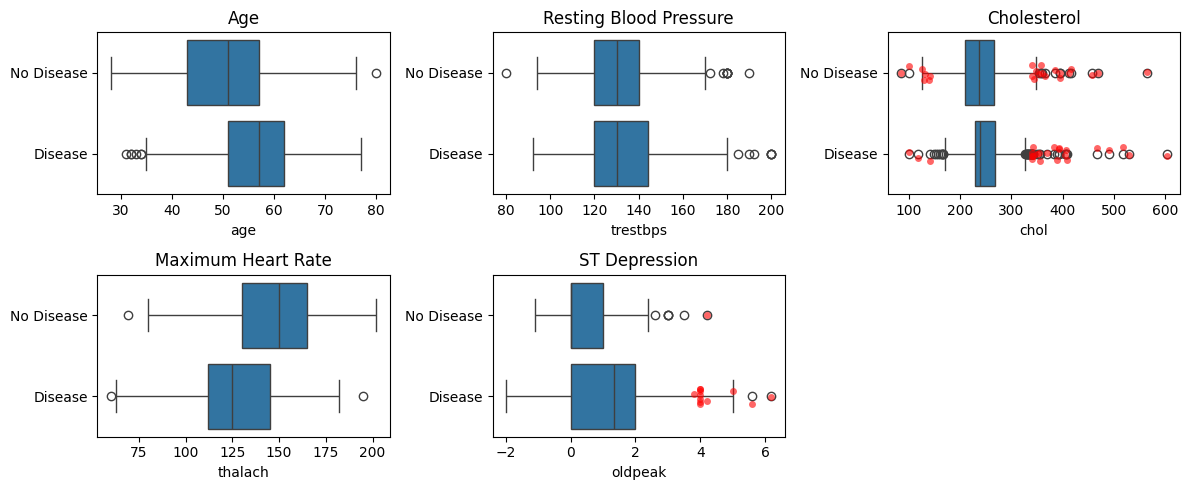

In [13]:
df['target_label'] = df['target'].map({0: 'No Disease', 1: 'Disease'})

chol_outlier_mask = (df['chol'] < chol_lb) | (df['chol'] > chol_ub)
oldpeak_outlier_mask = (df['oldpeak'] < op_lb) | (df['oldpeak'] > op_ub)

fig, ax = plt.subplots(2, 3, figsize=(12, 5))

sns.boxplot(data = df, x = 'age', y = 'target_label', ax = ax[0, 0])
ax[0, 0].set_title('Age')
ax[0, 0].set_ylabel('')
sns.boxplot(data = df, x = 'trestbps', y = 'target_label', ax = ax[0, 1])
ax[0, 1].set_title('Resting Blood Pressure')
ax[0, 1].set_ylabel('')
sns.boxplot(data = df, x = 'chol', y = 'target_label', ax = ax[0, 2])
sns.stripplot(
    data = df[chol_outlier_mask], 
    x = 'chol', 
    y = 'target_label', 
    ax = ax[0, 2], color = 'red', size = 5, alpha = 0.6
)
ax[0, 2].set_title('Cholesterol')
ax[0, 2].set_ylabel('')
sns.boxplot(data = df, x = 'thalach', y = 'target_label', ax = ax[1, 0])
ax[1, 0].set_title('Maximum Heart Rate')
ax[1, 0].set_ylabel('')
sns.boxplot(data = df, x = 'oldpeak', y = 'target_label', ax = ax[1, 1])
sns.stripplot(
    data = df[oldpeak_outlier_mask], 
    x = 'oldpeak', 
    y = 'target_label', 
    ax = ax[1, 1], color = 'red', size = 5, alpha = 0.6
)
ax[1, 1].set_title('ST Depression')
ax[1, 1].set_ylabel('')
ax[1, 2].set_visible(False)
plt.tight_layout()
plt.show()

In [14]:
df = df.drop(columns=['target_label'])

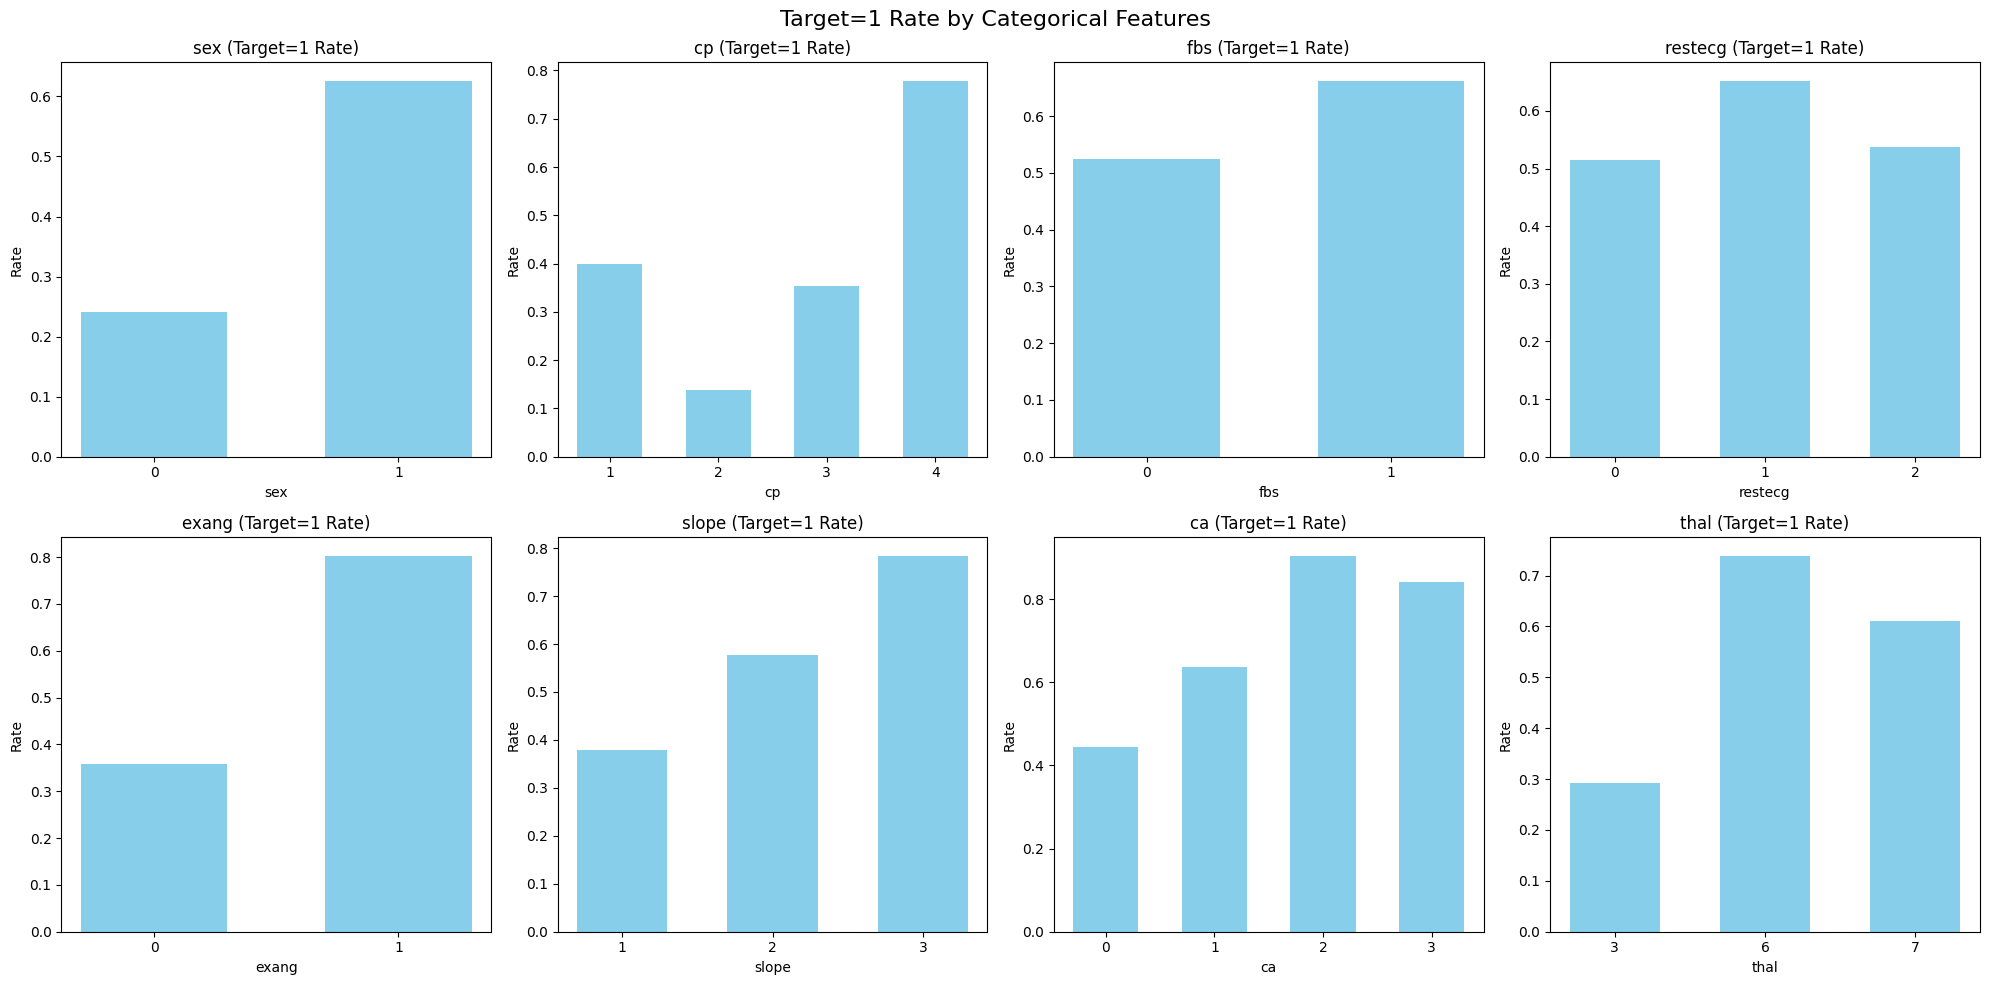

In [15]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, ax = plt.subplots(2, 4, figsize=(20, 10))
ax = ax.flatten()

for i, col in enumerate(cat_cols):
    rate = df.groupby(col)['target'].mean()
    
    positions = range(len(rate))
    ax[i].bar(positions, rate.values, color='skyblue', width=0.6)
    ax[i].set_xticks(positions)
    ax[i].set_xticklabels([int(v) for v in rate.index])
    ax[i].set_title(f'{col} (Target=1 Rate)')
    ax[i].set_ylabel('Rate')
    ax[i].set_xlabel(col)

plt.suptitle('Target=1 Rate by Categorical Features', fontsize=16)
plt.tight_layout()
plt.show()

### Correlation Analysis

cp          0.461776
oldpeak     0.372842
ca          0.350639
age         0.268983
thal        0.264206
slope       0.206819
trestbps    0.104782
chol        0.086074
restecg     0.041505
thalach    -0.385560
Name: target, dtype: float64


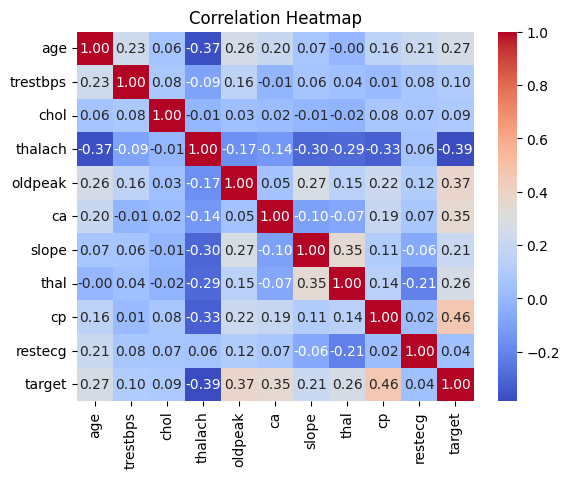

In [16]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'slope', 'thal', 'cp', 'restecg', 'target']

num_corr = df[num_cols].corr(numeric_only=True)['target'].drop('target').sort_values(ascending=False)
print(num_corr)

sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

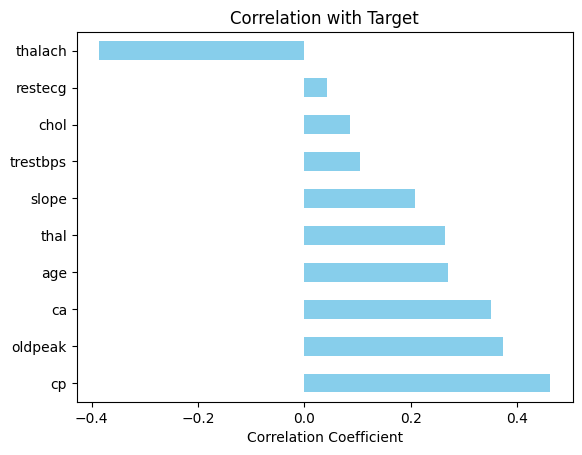

In [17]:
num_corr.plot(kind='barh', color='skyblue')
plt.title('Correlation with Target')
plt.xlabel('Correlation Coefficient')
plt.show()

In [18]:
df.shape

(908, 14)

In [19]:
gc.collect()

48065